# Segmentez les clients d'un site e-commerce

## Contexte de l'étude
Vous êtes consultant pour Olist, une entreprise brésilienne qui propose une solution de vente sur les marketplaces en ligne.

Votre objectif est de comprendre les différents types d’utilisateurs grâce à leur comportement et à leurs données personnelles.

Vous devrez fournir à l’équipe marketing une description actionable de votre segmentation et de sa logique sous-jacente pour une utilisation optimale, ainsi qu’une proposition de contrat de maintenance basée sur une analyse de la stabilité des segments au cours du temps.

## Contexte du notebook  
#### Etude de la stabilité.  

On décide de réaliser une étude permettant d'évaluer la fréquence des mises à jours du modèle de clustering des clients, lorsqu'on ajoute de nouveaux clients.
Pour ce faire, on va évaluer les prédictions des clusterings entre des périodes différentes d'entraînement.  

## Sommaire

- Importation des données

- Paramètres temporels

- Evaluation des fréquences de mise à jour

- Visualisation graphiques
    
# Importation des données

In [1]:
# Importation générale
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import joblib

In [2]:
# Importation des librairies pour la prédiction

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn import decomposition
# from sklearn import preprocessing
from sklearn.cluster import KMeans

from sklearn.pipeline import Pipeline
from sklearn import linear_model
from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import SVR
from sklearn import tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor

from sklearn.metrics.cluster import adjusted_rand_score

# Visualisation des diagrammes
from sklearn import set_config


In [3]:
# Permet d'élargir le notebook
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:70% !important; }</style>"))

In [4]:
## Import des données brutes et analyse de leur architecture

path_p4_local = r'D:\Utilisateurs\Damien\Documents\Test_code\test_python\OCR_projets\IML\P4_'
# path_p4_cloud = 

data_rfm = pd.read_csv(path_p4_local + r'\data_clean.csv',sep="\t",low_memory=False)
df_recency = pd.read_csv(path_p4_local + r'\df_recency.csv',sep="\t",low_memory=False)

In [5]:
data_rfm

,customer_unique_id,monetary,frequency,recency_days,mean_payment_installments,mean_review,mean_volume_cm3,mean_weight_g,mean_product_name_lenght,mean_product_description_lenght,mean_product_photos_qty,mean_delay_days
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,1,1548,8.0,5.0,7616.0,1500.0,60.0,236.0,1.0,6.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1,1551,1.0,4.0,5148.0,375.0,56.0,635.0,1.0,3.0
2,0000f46a3911fa3c0805444483337064,86.22,1,1973,8.0,3.0,43750.0,1500.0,49.0,177.0,3.0,25.0
3,0000f6ccb0745a6a4b88665a16c9f078,43.62,1,1757,4.0,4.0,1045.0,150.0,43.0,1741.0,5.0,20.0
4,0004aac84e0df4da2b147fca70cf8255,196.89,1,1724,6.0,5.0,528.0,6050.0,58.0,794.0,3.0,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...
91473,fffcf5a5ff07b0908bd4e2dbc735a684,4134.84,2,1883,10.0,5.0,251625.0,30000.0,54.0,478.5,1.0,27.0
91474,fffea47cd6d3cc0a88bd621562a9d061,84.58,1,1698,1.0,4.0,32076.0,1720.0,37.0,506.0,2.0,30.0
91475,ffff371b4d645b6ecea244b27531430a,112.46,1,2005,1.0,5.0,3315.0,600.0,57.0,716.0,5.0,14.0
91476,ffff5962728ec6157033ef9805bacc48,133.69,1,1556,5.0,5.0,4480.0,444.0,35.0,591.0,3.0,11.0


In [6]:
data_rfm_client = data_rfm.set_index("customer_unique_id")
data_rfm_client

,monetary,frequency,recency_days,mean_payment_installments,mean_review,mean_volume_cm3,mean_weight_g,mean_product_name_lenght,mean_product_description_lenght,mean_product_photos_qty,mean_delay_days
customer_unique_id,,,,,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,141.90,1,1548,8.0,5.0,7616.0,1500.0,60.0,236.0,1.0,6.0
0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1,1551,1.0,4.0,5148.0,375.0,56.0,635.0,1.0,3.0
0000f46a3911fa3c0805444483337064,86.22,1,1973,8.0,3.0,43750.0,1500.0,49.0,177.0,3.0,25.0
0000f6ccb0745a6a4b88665a16c9f078,43.62,1,1757,4.0,4.0,1045.0,150.0,43.0,1741.0,5.0,20.0
0004aac84e0df4da2b147fca70cf8255,196.89,1,1724,6.0,5.0,528.0,6050.0,58.0,794.0,3.0,13.0
...,...,...,...,...,...,...,...,...,...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,4134.84,2,1883,10.0,5.0,251625.0,30000.0,54.0,478.5,1.0,27.0
fffea47cd6d3cc0a88bd621562a9d061,84.58,1,1698,1.0,4.0,32076.0,1720.0,37.0,506.0,2.0,30.0
ffff371b4d645b6ecea244b27531430a,112.46,1,2005,1.0,5.0,3315.0,600.0,57.0,716.0,5.0,14.0


In [7]:
data_rfm_client.drop(['mean_volume_cm3','mean_weight_g','mean_product_name_lenght','mean_product_description_lenght'],axis=1,inplace=True)
data_rfm_client

,monetary,frequency,recency_days,mean_payment_installments,mean_review,mean_product_photos_qty,mean_delay_days
customer_unique_id,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,141.90,1,1548,8.0,5.0,1.0,6.0
0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1,1551,1.0,4.0,1.0,3.0
0000f46a3911fa3c0805444483337064,86.22,1,1973,8.0,3.0,3.0,25.0
0000f6ccb0745a6a4b88665a16c9f078,43.62,1,1757,4.0,4.0,5.0,20.0
0004aac84e0df4da2b147fca70cf8255,196.89,1,1724,6.0,5.0,3.0,13.0
...,...,...,...,...,...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,4134.84,2,1883,10.0,5.0,1.0,27.0
fffea47cd6d3cc0a88bd621562a9d061,84.58,1,1698,1.0,4.0,2.0,30.0
ffff371b4d645b6ecea244b27531430a,112.46,1,2005,1.0,5.0,5.0,14.0


In [8]:
# data_rfm_client.drop(['mean_product_photos_qty'],axis=1,inplace=True)
# data_rfm_client

In [9]:
df_recency

,customer_unique_id,LastPurchaseDate,recency_days,recency_years
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1548,4.241096
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1551,4.249315
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1973,5.405479
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1757,4.813699
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1724,4.723288
...,...,...,...,...
91473,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:00:36,1883,5.158904
91474,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10 20:07:56,1698,4.652055
91475,ffff371b4d645b6ecea244b27531430a,2017-02-07 15:49:16,2005,5.493151
91476,ffff5962728ec6157033ef9805bacc48,2018-05-02 15:17:41,1556,4.263014


# Paramètres temporels
0n crée nos paramètres ou constantes temporelles:

In [10]:
dt_start_2017 = pd.to_datetime('2017-01-01 00:00:00')
dt_start_2017

Timestamp('2017-01-01 00:00:00')

In [11]:
dt_start_2018 = pd.to_datetime('2018-01-01 00:00:00')
dt_start_2018

Timestamp('2018-01-01 00:00:00')

Période termporelle de 30 jours représentant 1 mois.

In [12]:
td = pd.Timedelta(30*1, "d")
td

Timedelta('30 days 00:00:00')

In [13]:
type(df_recency['LastPurchaseDate'][0])

str

In [14]:
df_recency['LastPurchaseDate'] =  pd.to_datetime(df_recency['LastPurchaseDate'])

In [15]:
type(df_recency['LastPurchaseDate'][0])

pandas._libs.tslibs.timestamps.Timestamp

In [16]:
df_recency['LastPurchaseDate'].max()

Timestamp('2018-08-29 15:00:37')

In [17]:
df_recency['LastPurchaseDate'].min()

Timestamp('2016-10-03 16:56:50')

In [18]:
# Première année
dt_oneyear = df_recency['LastPurchaseDate'].min() + 12*td
dt_oneyear

Timestamp('2017-09-28 16:56:50')

# Evaluation des fréquences de mise à jour
On crée une fonction nous permettant d'évaluer le ARI score de 2 clustering.
Pour des périodes d'entraînement T0 (date_inc) différentess, on prédira les clients sur une durée td puis on calculera le ARI score donné. On aura alors une liste de ARI liées au pr&dictions td fixées, sur différents T0 d'entraînement.

In [19]:
def stability_ari(n_clust,date_inc,td, data_rfm_client, df_recency):
    # n_clust: Nombre de clusters souhaités
    # date_inc = dt_start_2018 :  T0: Représente la période d'entraînement
    list_ari = []
    list_date = []
    list_nb_client = []

    while date_inc < df_recency['LastPurchaseDate'].max():
#         print('Start: ' + str(date_inc))

        # Segementation dataset < data_inc et dataset < data_inc + td
        id_list = df_recency[df_recency['LastPurchaseDate'] < date_inc]['customer_unique_id'].to_list()
        print('Effectif cumulé pour l''entraînement : ' + str(len(id_list)) + ' jusqu''à la date: ' + str(date_inc))
        id_list_next = df_recency[df_recency['LastPurchaseDate'] < date_inc + td]['customer_unique_id'].to_list()
        print('Effectif cumulé pour l''entraînement : ' + str(len(id_list_next)) + ' jusqu''à la date: ' + str(date_inc + td))
#         print(str(len(id_list_next)))

        # Calcul kmeans sur dataset < data_inc

        # Trf des données
        X_i = data_rfm_client[data_rfm_client.index.isin(id_list)].values #data_rfm[data_rfm['customer_unique_id'].isin(id_list)].values
        
        # Pipeline pour le clustering
        trf = PowerTransformer(method="box-cox")
        pipe_kmi = Pipeline(steps =[('trf', trf),('kmi',  KMeans(n_clusters=n_clust, init = 'k-means++', random_state = 42) )])
        pipe_kmi.fit(1+X_i)

        # Récupération des clusters attribués à chaque individu
        #clusters = pipe_kmi[1].labels_

        # Calcul kmeans sur dataset < data_inc + td

        # Trf des données
        X_i_next = data_rfm_client[data_rfm_client.index.isin(id_list_next)].values #data_rfm[data_rfm['customer_unique_id'].isin(id_list_next)].values
         # Pipeline pour le clustering
        trf_next = PowerTransformer(method="box-cox")
        pipe_kmi_next = Pipeline(steps =[('trf_next', trf_next),('kmi_next',  KMeans(n_clusters=n_clust, init = 'k-means++', random_state = 42) )])
        pipe_kmi_next.fit(1+X_i_next)

        # Récupération des clusters attribués à chaque individu
        #clusters = pipe_kmi_next[1].labels_

        # Calcul prediciton kmeans du dataset < data_inc sur data_inc+ td
        id_list_data_test = df_recency[ (df_recency['LastPurchaseDate'] >= date_inc) & (df_recency['LastPurchaseDate'] < date_inc + td) ]['customer_unique_id'].to_list()
        X_i_test = data_rfm_client[data_rfm_client.index.isin(id_list_data_test)].values #data_rfm[data_rfm['customer_unique_id'].isin(id_list_data_test)].values
        
        nb_client = len(id_list_data_test)

        # Calcul du ARI    
        ari = adjusted_rand_score(pipe_kmi_next.predict(1+X_i_test), pipe_kmi.predict(1+X_i_test))
        print('ari = ' + str(ari))
        list_ari.append(ari)
        list_date.append(date_inc)
        list_nb_client.append(nb_client)

        date_inc = date_inc + td
#         print('End: ' + str(date_inc))
        
    return [list_ari,list_date,list_nb_client]


On test la fonction pour la ise à jour sur une période de 1 mois, en modifiant mensuellement la date de l'entraînement:

In [20]:
list_stability_ari_evolutive = []
nb_freq_month = 1 #Jusqu'à qu'elle fréquence mensuelle on évalue le ari
nb_cluster = 7
data_inc = dt_start_2018 #date initiale de fin d'entraînement du k-means, et qui sera incrémenter par k*td

for k in range(1,nb_freq_month+1):
    [list_ari,list_date,list_nb_client] = stability_ari(nb_cluster,data_inc,k*td, data_rfm_client, df_recency)
    list_stability_ari_evolutive.append([list_ari,list_date,list_nb_client])

Effectif cumulé pour lentraînement : 40745 jusquà la date: 2018-01-01 00:00:00
Effectif cumulé pour lentraînement : 47129 jusquà la date: 2018-01-31 00:00:00
ari = 0.741332262558302
Effectif cumulé pour lentraînement : 47129 jusquà la date: 2018-01-31 00:00:00
Effectif cumulé pour lentraînement : 53765 jusquà la date: 2018-03-02 00:00:00
ari = 0.7598432745869238
Effectif cumulé pour lentraînement : 53765 jusquà la date: 2018-03-02 00:00:00
Effectif cumulé pour lentraînement : 60170 jusquà la date: 2018-04-01 00:00:00
ari = 0.9666517426427635
Effectif cumulé pour lentraînement : 60170 jusquà la date: 2018-04-01 00:00:00
Effectif cumulé pour lentraînement : 66709 jusquà la date: 2018-05-01 00:00:00
ari = 0.9851888994670414
Effectif cumulé pour lentraînement : 66709 jusquà la date: 2018-05-01 00:00:00
Effectif cumulé pour lentraînement : 73142 jusquà la date: 2018-05-31 00:00:00
ari = 0.6730822254314622
Effectif cumulé pour lentraînement : 73142 jusquà la date: 2018-05-31 00:00:00
Effecti

### Visualisations graphiques

On crée des foncitons pour pouvoir visualiser correctement les scores, avec le nombre de clients pour chaque mis-à-jour:  

In [21]:
# function to add text

def addtext(x,y):
    for i in range(len(x)):
        plt.text(i,y[i],y[i])

In [22]:
# function to add text

def addtext2(x,y,z):
    for i in range(len(x)):
        plt.text(i,y[i],z[i])

In [23]:
# function to add text

def addtext3(x,y,z):
    for i in range(len(x)):
        plt.text(x[i],y[i],(z[i],' clients prédits'))

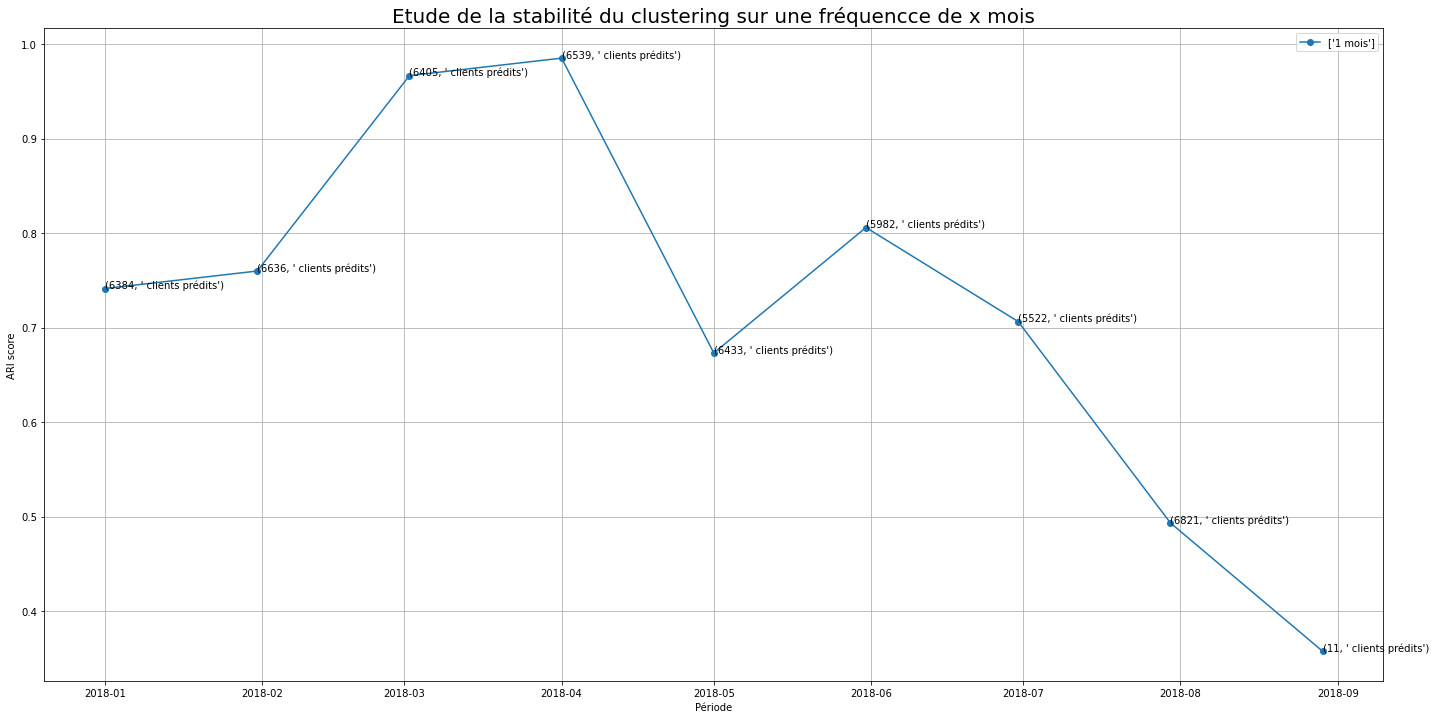

In [24]:
plt.figure(figsize=(24,12))
plt.title('Etude de la stabilité du clustering sur une fréquencce de x mois',fontsize=20)
plt.xlabel('Période')
plt.ylabel('ARI score')

text_legend = []
for k in range(nb_freq_month):
    plt.plot(list_stability_ari_evolutive[k][1],list_stability_ari_evolutive[k][0],marker='o')
    addtext3(list_stability_ari_evolutive[k][1],list_stability_ari_evolutive[k][0],list_stability_ari_evolutive[k][2])
    text_legend.append([str(k+1) + ' mois'])

plt.legend(text_legend)
plt.grid()
plt.show()

Les dates en abcisses sont les dates à partir desquelles il y a des nouveaux clients qui commandent chaque mois. On notifie ce nombre de clients sur le point en ordonnée du ARI score.

On calcule la stabilité sur plusieurs périodes fréquentielles:

In [23]:
list_stability_ari_evolutive = []
nb_freq_month = 5 #Jusqu'à qu'elle fréquence mensuelle on évalue le ari
nb_cluster = 7
data_inc = dt_start_2018 #date initiale de fin d'entraînement du k-means, et qui sera incrémenter par k*td

for k in range(1,nb_freq_month+1):
    [list_ari,list_date,list_nb_client] = stability_ari(nb_cluster,data_inc,k*td, data_rfm_client, df_recency)
    list_stability_ari_evolutive.append([list_ari,list_date,list_nb_client])

Effectif cumulé pour lentraînement : 40745 jusquà la date: 2018-01-01 00:00:00
Effectif cumulé pour lentraînement : 47129 jusquà la date: 2018-01-31 00:00:00
ari = 0.741332262558302
Effectif cumulé pour lentraînement : 47129 jusquà la date: 2018-01-31 00:00:00
Effectif cumulé pour lentraînement : 53765 jusquà la date: 2018-03-02 00:00:00
ari = 0.7598432745869238
Effectif cumulé pour lentraînement : 53765 jusquà la date: 2018-03-02 00:00:00
Effectif cumulé pour lentraînement : 60170 jusquà la date: 2018-04-01 00:00:00
ari = 0.9666517426427635
Effectif cumulé pour lentraînement : 60170 jusquà la date: 2018-04-01 00:00:00
Effectif cumulé pour lentraînement : 66709 jusquà la date: 2018-05-01 00:00:00
ari = 0.9851888994670414
Effectif cumulé pour lentraînement : 66709 jusquà la date: 2018-05-01 00:00:00
Effectif cumulé pour lentraînement : 73142 jusquà la date: 2018-05-31 00:00:00
ari = 0.6730822254314622
Effectif cumulé pour lentraînement : 73142 jusquà la date: 2018-05-31 00:00:00
Effecti

Visualisation synthétique

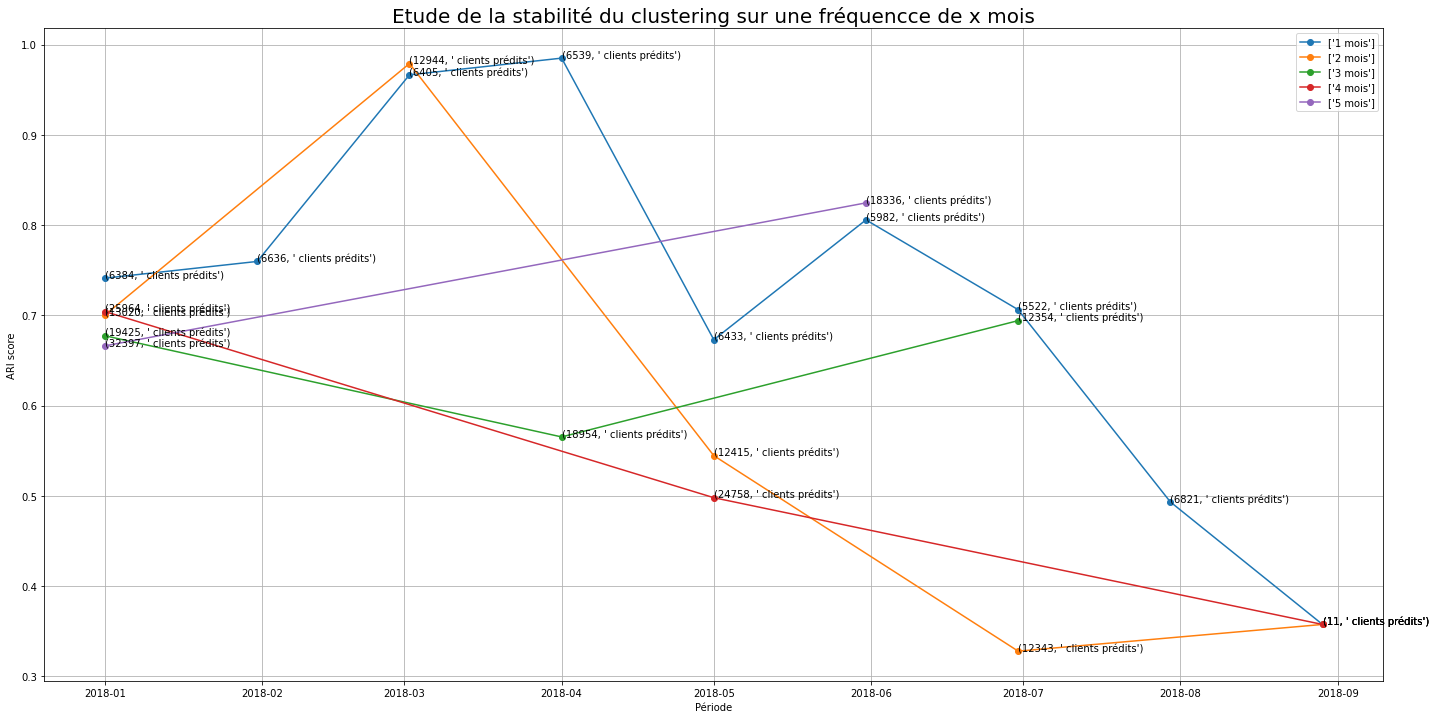

In [30]:
plt.figure(figsize=(24,12))
plt.title('Etude de la stabilité du clustering sur une fréquencce de x mois',fontsize=20)
plt.xlabel('Période')
plt.ylabel('ARI score')

text_legend = []
for k in range(nb_freq_month):
    plt.plot(list_stability_ari_evolutive[k][1],list_stability_ari_evolutive[k][0],marker='o')
    addtext3(list_stability_ari_evolutive[k][1],list_stability_ari_evolutive[k][0],list_stability_ari_evolutive[k][2])
    text_legend.append([str(k+1) + ' mois'])

plt.legend(text_legend)
plt.grid()
plt.show()

On obtient une tendence détaillée des graphes selon la fréquence de mise à jour donnée.

Dans l'ensemble, une mise à jour petite donne un bon ARI score en début d'étude. Mais ce score semble relativement impacté par le nombre de clients ou de nouvelles commandes, ou plus généralement le comportement des clients qui peut devenir très différents d'un période à une autre.

On émet l'hhypothèse future d'une étude comparative sur une mise à jour non plus sur une fréquence de date particulière, mais plutôt sur un nombre de nouveau client ou de nouvelle commande. 

### Moyenne des stabilités  
On décide de calculer la moyenne pour chaque courbe de mois, et dégager la tendance générale pour une prédiction d'une période donnée:

In [33]:
list_stability_ari_evolutive_moy = []
for k in range(len(list_stability_ari_evolutive)):
    list_stability_ari_evolutive_moy.append(np.mean(list_stability_ari_evolutive[k][0]))
list_stability_ari_evolutive_moy

[0.7210136138350166,
 0.5819281071117747,
 0.6456751562756865,
 0.5199005149930158,
 0.7455269124508515]

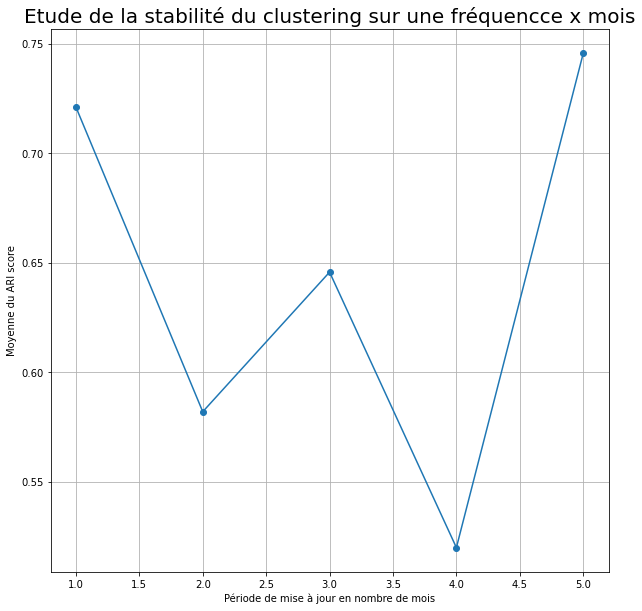

In [37]:
plt.figure(figsize=(10,10))
plt.title('Etude de la stabilité du clustering sur une fréquencce x mois',fontsize=20)
plt.xlabel('Période de mise à jour en nombre de mois')
plt.ylabel('Moyenne du ARI score')
plt.plot(range(1,len(list_stability_ari_evolutive_moy)+1),list_stability_ari_evolutive_moy,marker='o')
# plt.text(list_date,list_ari+0.1,str(list_nb_client))
# addtext3(list_k,list_ari,list_nb_client)
plt.grid()
plt.show()

La courbe représentée ne possède par d'évolution particulière (monootonie, parabole, ...). En réalité, la moyenne sur la mise à jour sur 5 mois est très étonnante car elle donne un ARI score meilleure que pour toutes les autres fréquences de mise à jour, et en particuliers pour la période de 1 mois.   
On déicde de modifier ma date initiale de fin d'entraînement ('data_inc') qui modiifie le nombre d'individus entrainés au départ, et voir ainsi l'impact sur ces scores.

## Etude précoce: Réduction du dataset d'entraînement initale

In [38]:

list_stability_ari_evolutive = []
nb_freq_month = 5 #Jusqu'à qu'elle fréquence mensuelle on évalue le ari
nb_cluster = 7
data_inc = dt_start_2017 #date initiale de fin d'entraînement du k-means, et qui sera incrémenter par k*td

for k in range(1,nb_freq_month+1):
    [list_ari,list_date,list_nb_client] = stability_ari(nb_cluster,data_inc,k*td, data_rfm_client, df_recency)
    list_stability_ari_evolutive.append([list_ari,list_date,list_nb_client])

Effectif cumulé pour lentraînement : 253 jusquà la date: 2017-01-01 00:00:00
Effectif cumulé pour lentraînement : 866 jusquà la date: 2017-01-31 00:00:00


C:\Users\daims\anaconda3\lib\site-packages\scipy\stats\morestats.py:912: RuntimeWarning: overflow encountered in power
  variance = np.var(data**lmb / lmb, axis=0)
C:\Users\daims\anaconda3\lib\site-packages\numpy\core\_methods.py:232: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
C:\Users\daims\anaconda3\lib\site-packages\numpy\core\_methods.py:243: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)
C:\Users\daims\anaconda3\lib\site-packages\scipy\stats\morestats.py:914: RuntimeWarning: divide by zero encountered in log
  return (lmb - 1) * np.sum(logdata, axis=0) - N/2 * np.log(variance)


ari = 0.12437217264262794
Effectif cumulé pour lentraînement : 866 jusquà la date: 2017-01-31 00:00:00
Effectif cumulé pour lentraînement : 2538 jusquà la date: 2017-03-02 00:00:00


C:\Users\daims\anaconda3\lib\site-packages\scipy\stats\morestats.py:914: RuntimeWarning: divide by zero encountered in log
  return (lmb - 1) * np.sum(logdata, axis=0) - N/2 * np.log(variance)
C:\Users\daims\anaconda3\lib\site-packages\scipy\stats\morestats.py:914: RuntimeWarning: divide by zero encountered in log
  return (lmb - 1) * np.sum(logdata, axis=0) - N/2 * np.log(variance)


ari = 0.5146686460264774
Effectif cumulé pour lentraînement : 2538 jusquà la date: 2017-03-02 00:00:00
Effectif cumulé pour lentraînement : 4810 jusquà la date: 2017-04-01 00:00:00


...

ari = 0.7984481766400832
Effectif cumulé pour lentraînement : 12988 jusquà la date: 2017-06-30 00:00:00
Effectif cumulé pour lentraînement : 24105 jusquà la date: 2017-09-28 00:00:00
ari = 0.836281394831229
Effectif cumulé pour lentraînement : 24105 jusquà la date: 2017-09-28 00:00:00
Effectif cumulé pour lentraînement : 40189 jusquà la date: 2017-12-27 00:00:00
ari = 0.687188070710371
Effectif cumulé pour lentraînement : 40189 jusquà la date: 2017-12-27 00:00:00
Effectif cumulé pour lentraînement : 59253 jusquà la date: 2018-03-27 00:00:00
ari = 0.9109987329929804
Effectif cumulé pour lentraînement : 59253 jusquà la date: 2018-03-27 00:00:00
Effectif cumulé pour lentraînement : 78048 jusquà la date: 2018-06-25 00:00:00
ari = 0.7238648142009624
Effectif cumulé pour lentraînement : 78048 jusquà la date: 2018-06-25 00:00:00
Effectif cumulé pour lentraînement : 91478 jusquà la date: 2018-09-23 00:00:00
ari = 0.8761921250914999
Effectif cumulé pour lentraînement : 253 jusquà la date: 2017-

C:\Users\daims\anaconda3\lib\site-packages\scipy\stats\morestats.py:912: RuntimeWarning: overflow encountered in power
  variance = np.var(data**lmb / lmb, axis=0)
C:\Users\daims\anaconda3\lib\site-packages\numpy\core\_methods.py:232: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
C:\Users\daims\anaconda3\lib\site-packages\numpy\core\_methods.py:243: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


ari = 0.060780768667121815
Effectif cumulé pour lentraînement : 6932 jusquà la date: 2017-05-01 00:00:00
Effectif cumulé pour lentraînement : 20161 jusquà la date: 2017-08-29 00:00:00
ari = 0.9008613252116995
Effectif cumulé pour lentraînement : 20161 jusquà la date: 2017-08-29 00:00:00
Effectif cumulé pour lentraînement : 40189 jusquà la date: 2017-12-27 00:00:00
ari = 0.6936843915124603
Effectif cumulé pour lentraînement : 40189 jusquà la date: 2017-12-27 00:00:00
Effectif cumulé pour lentraînement : 65688 jusquà la date: 2018-04-26 00:00:00
ari = 0.9225184793598941
Effectif cumulé pour lentraînement : 65688 jusquà la date: 2018-04-26 00:00:00
Effectif cumulé pour lentraînement : 91128 jusquà la date: 2018-08-24 00:00:00
ari = 0.5039077145063068
Effectif cumulé pour lentraînement : 91128 jusquà la date: 2018-08-24 00:00:00
Effectif cumulé pour lentraînement : 91478 jusquà la date: 2018-12-22 00:00:00
ari = 0.44103707600283915
Effectif cumulé pour lentraînement : 253 jusquà la date: 2

C:\Users\daims\anaconda3\lib\site-packages\scipy\stats\morestats.py:912: RuntimeWarning: overflow encountered in power
  variance = np.var(data**lmb / lmb, axis=0)
C:\Users\daims\anaconda3\lib\site-packages\numpy\core\_methods.py:232: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
C:\Users\daims\anaconda3\lib\site-packages\numpy\core\_methods.py:243: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


ari = 0.065817605015435
Effectif cumulé pour lentraînement : 10072 jusquà la date: 2017-05-31 00:00:00
Effectif cumulé pour lentraînement : 28190 jusquà la date: 2017-10-28 00:00:00
ari = 0.7900280844669485
Effectif cumulé pour lentraînement : 28190 jusquà la date: 2017-10-28 00:00:00
Effectif cumulé pour lentraînement : 59253 jusquà la date: 2018-03-27 00:00:00
ari = 0.6916645157341637
Effectif cumulé pour lentraînement : 59253 jusquà la date: 2018-03-27 00:00:00
Effectif cumulé pour lentraînement : 91128 jusquà la date: 2018-08-24 00:00:00
ari = 0.5181403378682635
Effectif cumulé pour lentraînement : 91128 jusquà la date: 2018-08-24 00:00:00
Effectif cumulé pour lentraînement : 91478 jusquà la date: 2019-01-21 00:00:00
ari = 0.44103707600283915


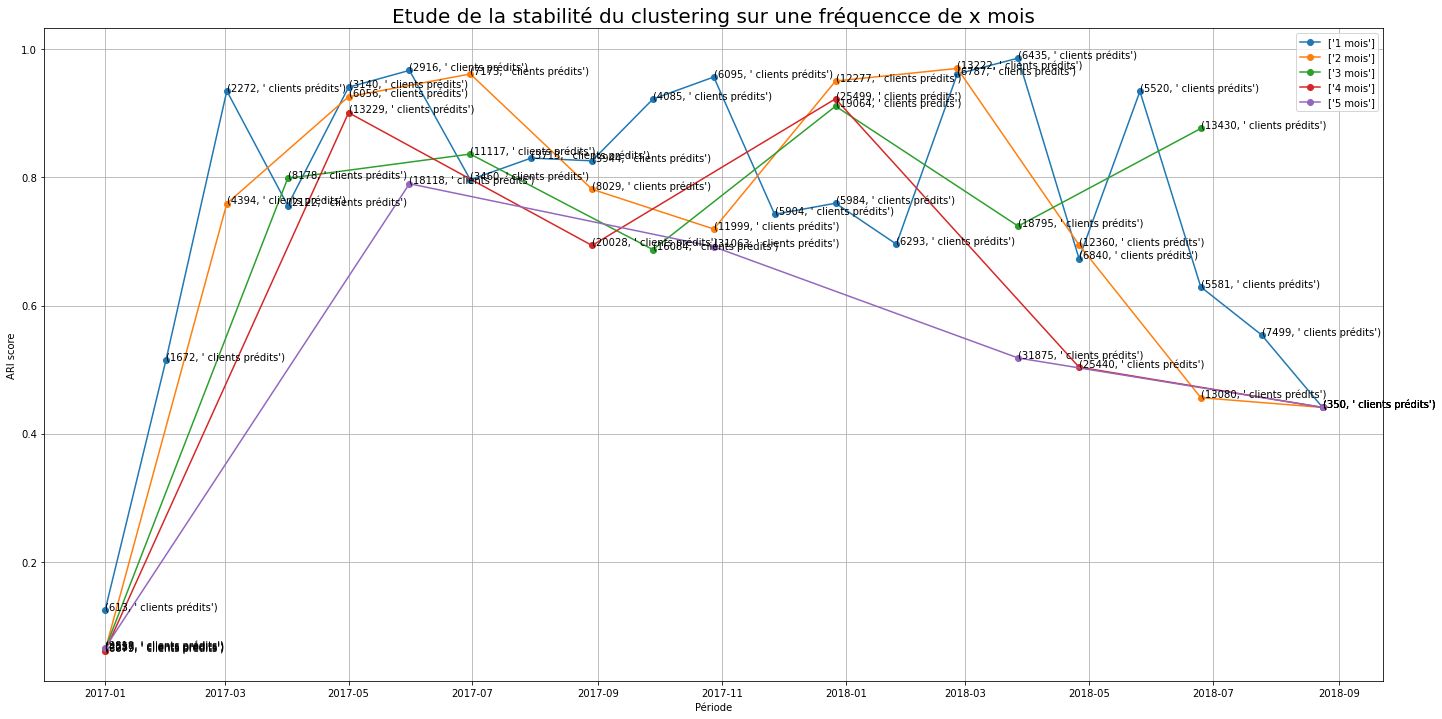

In [39]:
plt.figure(figsize=(24,12))
plt.title('Etude de la stabilité du clustering sur une fréquencce de x mois',fontsize=20)
plt.xlabel('Période')
plt.ylabel('ARI score')

text_legend = []
for k in range(nb_freq_month):
    plt.plot(list_stability_ari_evolutive[k][1],list_stability_ari_evolutive[k][0],marker='o')
    addtext3(list_stability_ari_evolutive[k][1],list_stability_ari_evolutive[k][0],list_stability_ari_evolutive[k][2])
    text_legend.append([str(k+1) + ' mois'])

plt.legend(text_legend)
plt.grid()
plt.show()

Ici, la première occurrence du dataset entraîné est réalisé jusqu'au 1er javier 2017, donc 1 an de clients en moins au début de l'entraînement, comparé aux graphiques précédents.  
La tendance détaillée semble montrer des scores moins bons lorsquela période de mise à jour est plus étalée. Vérifions celà en traçant la moyenne de ce graphique:

In [40]:
list_stability_ari_evolutive_moy = []
for k in range(len(list_stability_ari_evolutive)):
    list_stability_ari_evolutive_moy.append(np.mean(list_stability_ari_evolutive[k][0]))
list_stability_ari_evolutive_moy

[0.7592382611996996,
 0.7018581859417126,
 0.6995430487311786,
 0.5871316258767203,
 0.5013375238175299]

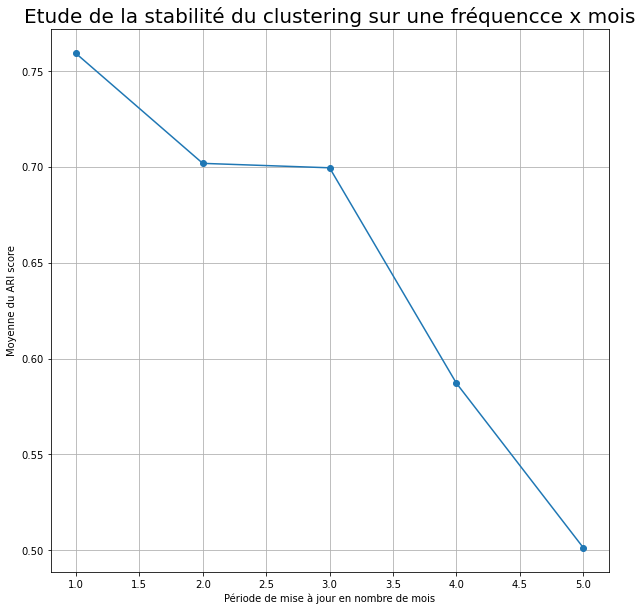

In [41]:
plt.figure(figsize=(10,10))
plt.title('Etude de la stabilité du clustering sur une fréquencce x mois',fontsize=20)
plt.xlabel('Période de mise à jour en nombre de mois')
plt.ylabel('Moyenne du ARI score')
plt.plot(range(1,len(list_stability_ari_evolutive_moy)+1),list_stability_ari_evolutive_moy,marker='o')
# plt.text(list_date,list_ari+0.1,str(list_nb_client))
# addtext3(list_k,list_ari,list_nb_client)
plt.grid()
plt.show()

Dans ce nouveau graphique, on constate clairement la tendace générale du score qui chute avec l'agrandissement de la période de mise à jour.  
L'ARI score est en moyenne au dessus de 0.75 pour une mise à jour de 1 mois, à 0.70 pour 2 et 3 mois, en dessosu de 0.6 pour 4 mois et à 0.5 pour 5 mois.  
Au vu des résultats et de la forme des courbes de la tendance détaillée, une mise de 1 mois semble le plus préconisé.

### Etude complémentaire non nécessaire

On effectue un test ici avec une période initiale d'entraînement sur 1 ans, que l'on étendra par la suite.
T0 = 1 ans.

In [28]:

list_stability_ari_evolutive = []
nb_freq_month = 5 #Jusqu'à qu'elle fréquence mensuelle on évalue le ari
nb_cluster = 7
data_inc = dt_oneyear #date initiale de fin d'entraînement du k-means, et qui sera incrémenter par k*td

for k in range(1,nb_freq_month+1):
    [list_ari,list_date,list_nb_client] = stability_ari(nb_cluster,data_inc,k*td, data_rfm_client, df_recency)
    list_stability_ari_evolutive.append([list_ari,list_date,list_nb_client])

Effectif cumulé pour lentraînement : 24184 jusquà la date: 2017-09-28 16:56:50
Effectif cumulé pour lentraînement : 28237 jusquà la date: 2017-10-28 16:56:50
ari = 0.7134193503993816
Effectif cumulé pour lentraînement : 28237 jusquà la date: 2017-10-28 16:56:50
Effectif cumulé pour lentraînement : 34506 jusquà la date: 2017-11-27 16:56:50
ari = 0.7469994800196578
Effectif cumulé pour lentraînement : 34506 jusquà la date: 2017-11-27 16:56:50
Effectif cumulé pour lentraînement : 40264 jusquà la date: 2017-12-27 16:56:50
ari = 0.748694130961254
Effectif cumulé pour lentraînement : 40264 jusquà la date: 2017-12-27 16:56:50
Effectif cumulé pour lentraînement : 46317 jusquà la date: 2018-01-26 16:56:50
ari = 0.7732580540157208
Effectif cumulé pour lentraînement : 46317 jusquà la date: 2018-01-26 16:56:50
Effectif cumulé pour lentraînement : 52581 jusquà la date: 2018-02-25 16:56:50
ari = 0.7240072799853499
Effectif cumulé pour lentraînement : 52581 jusquà la date: 2018-02-25 16:56:50
Effecti

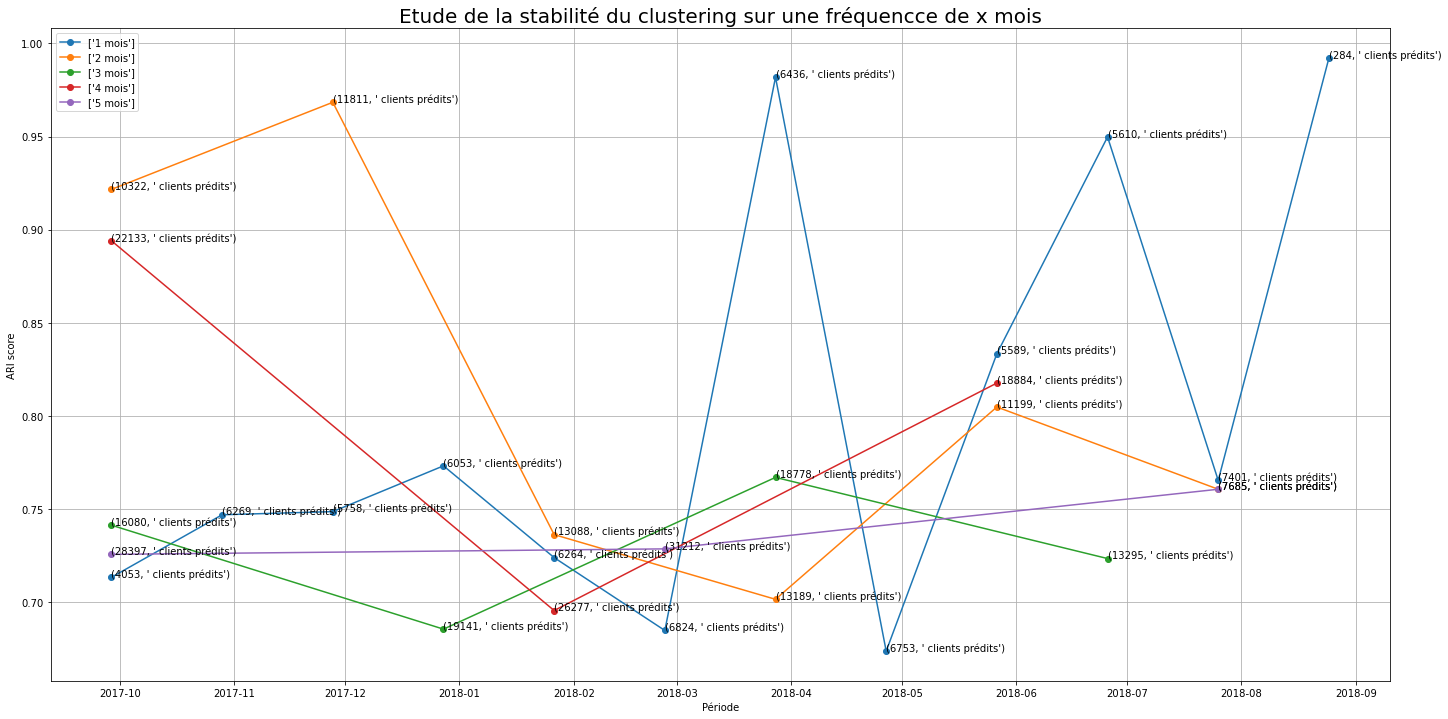

In [29]:
plt.figure(figsize=(24,12))
plt.title('Etude de la stabilité du clustering sur une fréquencce de x mois',fontsize=20)
plt.xlabel('Période')
plt.ylabel('ARI score')

text_legend = []
for k in range(nb_freq_month):
    plt.plot(list_stability_ari_evolutive[k][1],list_stability_ari_evolutive[k][0],marker='o')
    addtext3(list_stability_ari_evolutive[k][1],list_stability_ari_evolutive[k][0],list_stability_ari_evolutive[k][2])
    text_legend.append([str(k+1) + ' mois'])

plt.legend(text_legend)
plt.grid()
plt.show()

In [30]:
list_stability_ari_evolutive_moy = []
for k in range(len(list_stability_ari_evolutive)):
    list_stability_ari_evolutive_moy.append(np.mean(list_stability_ari_evolutive[k][0]))
list_stability_ari_evolutive_moy

[0.7989769191870373,
 0.8155946457921326,
 0.7293964210729895,
 0.8024559748005947,
 0.7383746515533455]

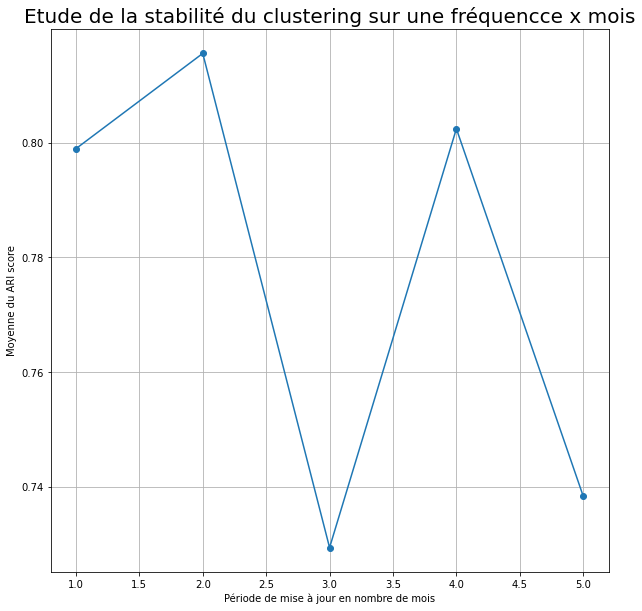

In [31]:
plt.figure(figsize=(10,10))
plt.title('Etude de la stabilité du clustering sur une fréquencce x mois',fontsize=20)
plt.xlabel('Période de mise à jour en nombre de mois')
plt.ylabel('Moyenne du ARI score')
plt.plot(range(1,len(list_stability_ari_evolutive_moy)+1),list_stability_ari_evolutive_moy,marker='o')
# plt.text(list_date,list_ari+0.1,str(list_nb_client))
# addtext3(list_k,list_ari,list_nb_client)
plt.grid()
plt.show()